In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
df.shape

(7043, 21)

In [ ]:
df.value_counts("Churn") ## IMBALANCED DATASET

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
df = df.drop("customerID",axis=1)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# Check current dtype
print(df["TotalCharges"].dtype)
## We came to know that total charges has blank spaces, as it should have been int or float, as it has the numeric value, but it is a string. Therefore, some blank spaces might be there. That's how we guess from da.info. 
# Replace blank strings with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Verify
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isna().sum())

str
float64
11


In [ ]:
df[df["TotalCharges"].isna()] #Inspecting the missing rows. 
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "Churn"]] #Came to a conclusion that dropping the mob will be better, as this is not useful data. They don't have tenure, and churn is no, so it's best to drop them. 

,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


In [ ]:
df = df.dropna(subset=["TotalCharges"]) #removes rows where that specific column is null.

In [28]:
df.shape
df.isna().sum()
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [29]:
df.duplicated().sum()

np.int64(22)

In [31]:
target_col = "Churn"
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [col for col in df.columns if col not in [target_col] + numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
#Analyzing the target 
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)


Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

## Univariate Analysis

Univariate analysis studies one feature at a time to understand its distribution, spread, skewness, range, and overall behavior. In this notebook, univariate analysis is used to inspect the numerical and categorical features individually before analyzing how they relate to the target variable `Churn`.

This helps identify:
- skewed or unusual distributions
- potential outliers
- dominant categories
- feature-level patterns that may influence preprocessing and later modeling decisions

In [33]:
#for tenure 
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

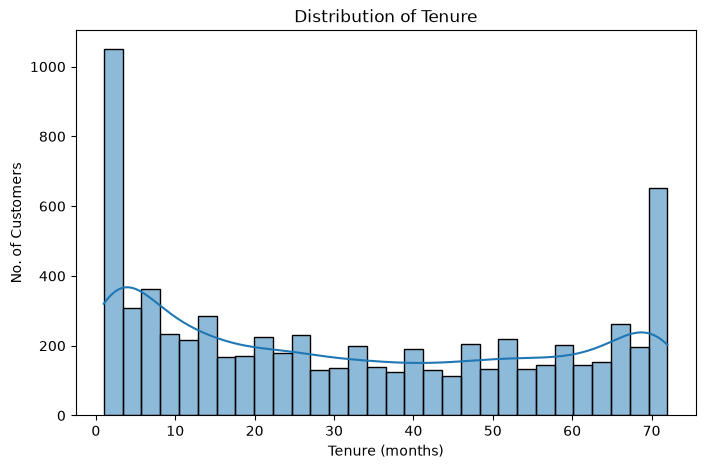

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("No. of Customers")
plt.show()

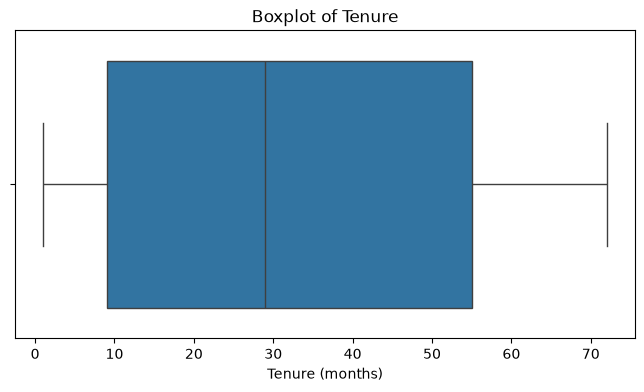

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["tenure"])
plt.title("Boxplot of Tenure")
plt.xlabel("Tenure (months)")
plt.show()

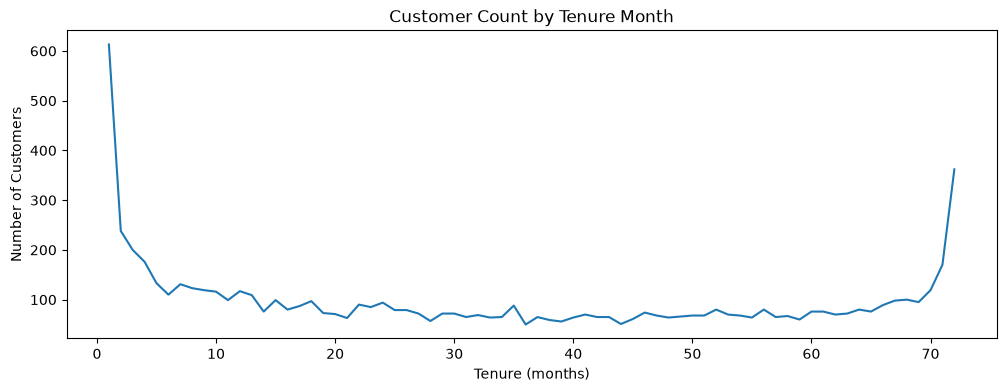

In [37]:
df["tenure"].value_counts().sort_index().plot(figsize=(12,4))
plt.title("Customer Count by Tenure Month")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

### Observations — Tenure
- `tenure` represents the number of months a customer has stayed with the telecom provider.
- The distribution is not bell-shaped; it shows a high concentration of customers at very low tenure and another concentration near the highest tenure values.
- This suggests the customer base contains both many newly acquired customers and many long-standing customers, with comparatively fewer customers in some middle-tenure ranges.
- The boxplot shows a wide spread in tenure values and no obvious extreme outliers.
- Since customer lifetime is strongly tied to retention behavior, `tenure` is expected to be an important predictor of churn.

In [38]:
df["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

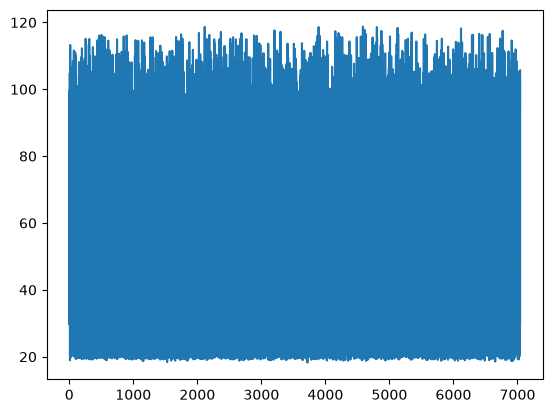

In [39]:
plt.Figure(figsize=(8,4))
plt.plot(df["MonthlyCharges"])
plt.show()

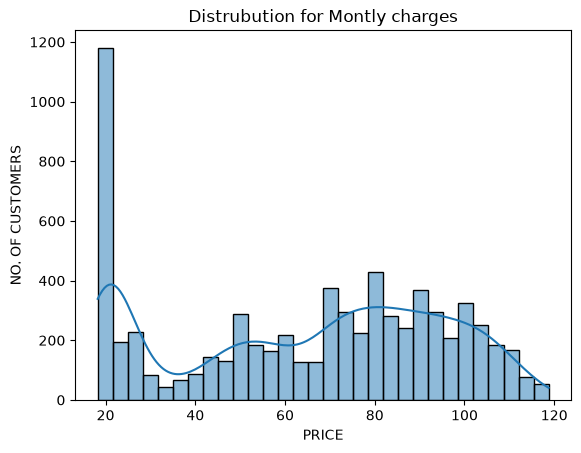

In [43]:
plt.Figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], kde=True, bins=30)
plt.title("Distrubution for Montly charges")
plt.xlabel("PRICE")
plt.ylabel("NO. OF CUSTOMERS")
plt.show()

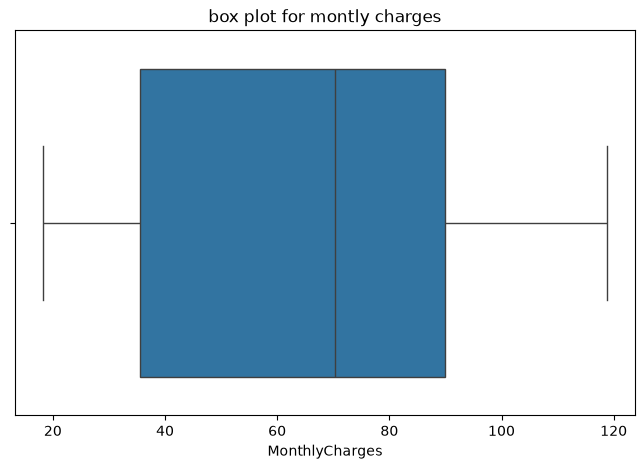

'A boxplot summarizes the distribution of MonthlyCharges using:\n\nminimum\nQ1 (25th percentile)\nmedian\nQ3 (75th percentile)\nmaximum\nand possible outliers if any exist'

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["MonthlyCharges"])
plt.title('box plot for montly charges')
plt.show()
'''A boxplot summarizes the distribution of MonthlyCharges using:

minimum
Q1 (25th percentile)
median
Q3 (75th percentile)
maximum
and possible outliers if any exist'''

### Observations — Monthly Charges
- `MonthlyCharges` shows a wide range of customer billing amounts, indicating meaningful variation in plan pricing and subscribed services.
- A large concentration of customers lies in the low-charge range, while another broad concentration appears in the medium-to-high charge range.
- The distribution is not bell-shaped and appears to contain multiple pricing clusters, which may reflect different service bundles or subscription plans.
- Since billing amount can influence perceived value and affordability, `MonthlyCharges` is likely to be an important feature in churn analysis.

In [44]:
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

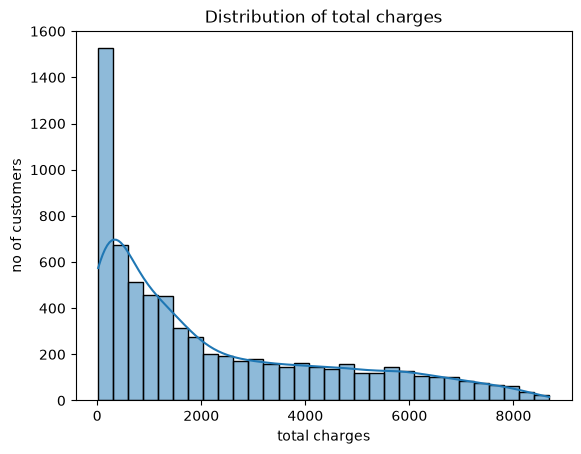

In [46]:
plt.Figure(figsize=(8,5))
sns.histplot(df['TotalCharges'], kde=True, bins=30)
plt.title("Distribution of total charges")
plt.xlabel('total charges')
plt.ylabel('no of customers')
plt.show()

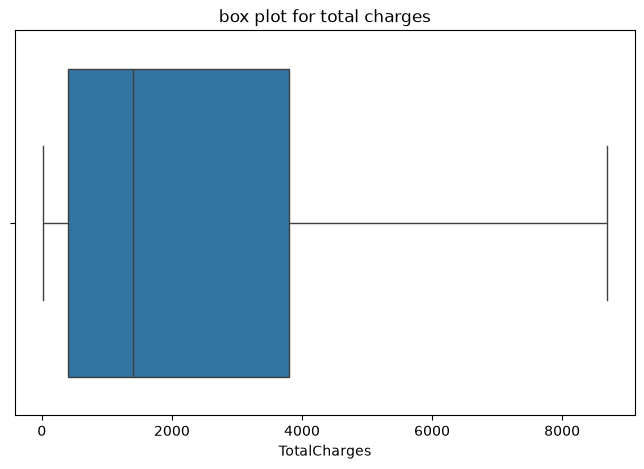

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalCharges"])
plt.title('box plot for total charges')
plt.show()

### Observations — TotalCharges
- `TotalCharges` shows a strongly right-skewed distribution, with a large concentration of customers at lower total billed amounts and a long tail extending toward high values.
- This pattern is expected because `TotalCharges` is a cumulative variable influenced by both customer tenure and monthly billing amount.
- The boxplot confirms a wide spread in total customer spend, with higher values likely corresponding to long-tenure customers and/or customers on higher monthly plans.
- The feature appears business-meaningful and is likely to be important for churn modeling, but its skewness should be kept in mind during preprocessing and model interpretation.

## Bivariate Analysis

Bivariate analysis studies the relationship between two variables. In this project, it is used to understand how each feature relates to the target variable `Churn`.

Unlike univariate analysis, which examines a feature in isolation, bivariate analysis helps answer whether a feature shows different behavior across churned and non-churned customers. This is important for identifying strong churn drivers, generating business insights, and understanding which features are likely to be useful for modeling.

In [50]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


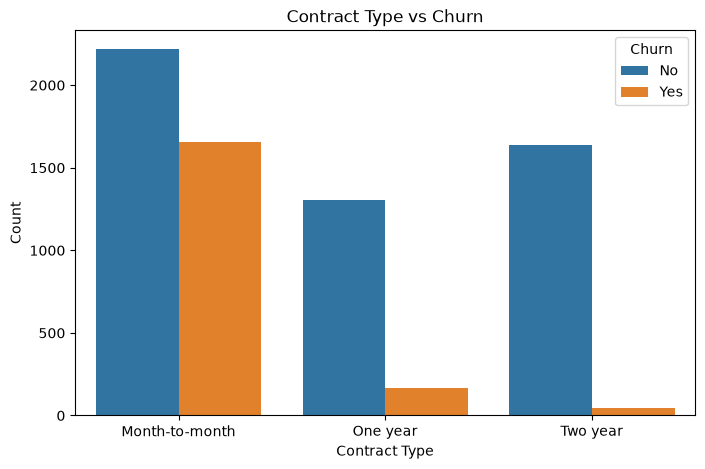

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

In [55]:
# 3. Churn rate by contract type
contract_churn = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

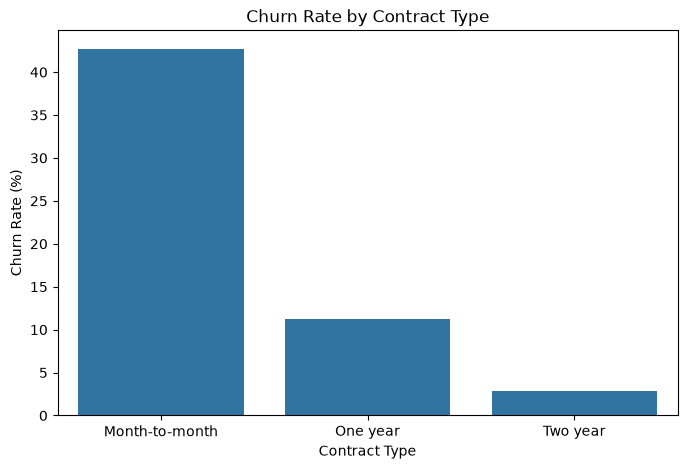

In [56]:
# 4. Plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

### Observations — Contract vs Churn
- Customers on month-to-month contracts show the highest churn rate among the three contract categories.
- Customers with one-year and especially two-year contracts have much lower churn rates.
- This suggests that longer contract commitments are associated with stronger customer retention.
- `Contract` appears to be one of the most important categorical predictors of churn in this dataset.

In [57]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


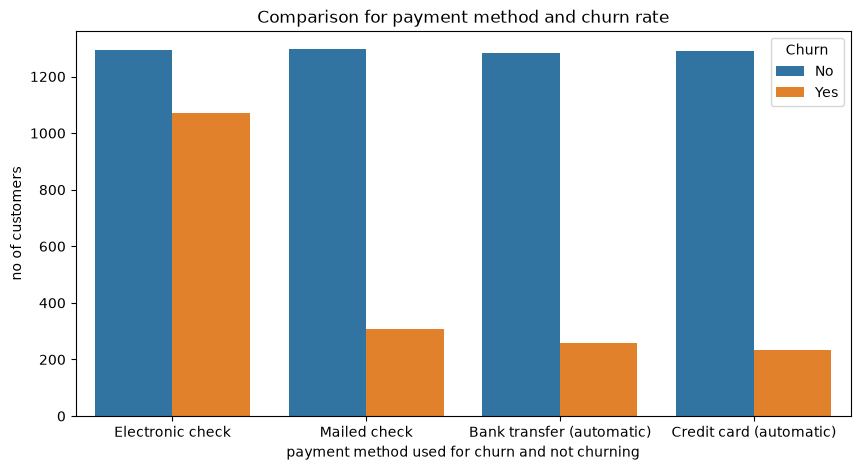

In [63]:
plt.figure(figsize=(10,5))
sns.countplot(data= df,hue=df["Churn"], x=df['PaymentMethod'])
plt.title("Comparison for payment method and churn rate")
plt.ylabel('no of customers')
plt.xlabel('payment method used for churn and not churning')
plt.show()

In [64]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

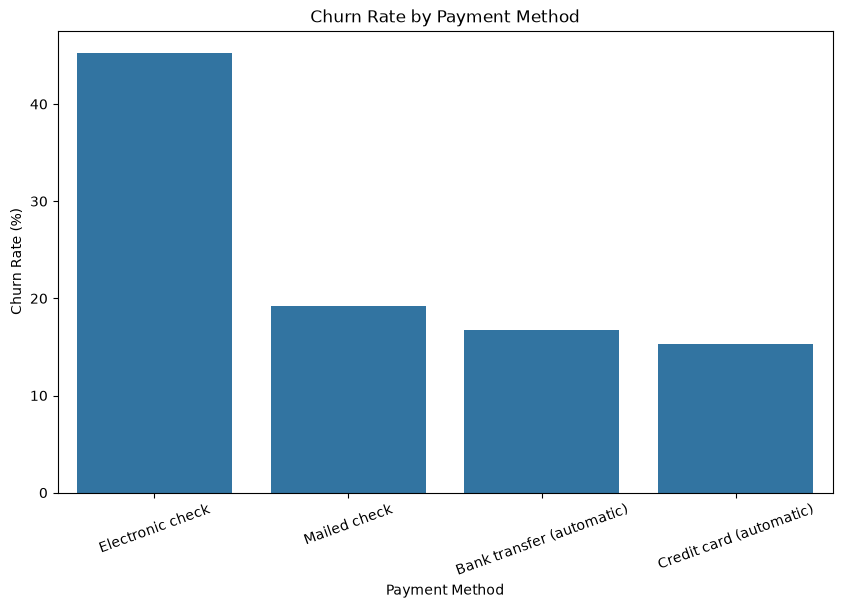

In [66]:
plt.figure(figsize=(10,6))
sns.barplot(x=payment_churn.index, y=payment_churn.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

### Observations — PaymentMethod vs Churn
- Customers using **Electronic check** appear to have the highest number of churn cases among the payment methods.
- Customers using **Bank transfer (automatic)** and **Credit card (automatic)** show comparatively fewer churn cases.
- This suggests that payment method may be associated with customer retention behavior, although churn-rate percentages should be checked before drawing final conclusions.

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def categorical_vs_churn(df, col, target="Churn", figsize=(10,5), rotate_xticks=False):
    # Crosstab
    print(f"\n===== Crosstab: {col} vs {target} =====")
    display(pd.crosstab(df[col], df[target]))

    # Countplot
    plt.figure(figsize=figsize)
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel("Count")
    if rotate_xticks:
        plt.xticks(rotation=20)
    plt.show()

    # Churn rate calculation
    churn_rate = (
        df.groupby(col)[target]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
    )

    print(f"\n===== Churn Rate by {col} =====")
    display(churn_rate)

    # Churn rate plot
    plt.figure(figsize=figsize)
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    if rotate_xticks:
        plt.xticks(rotation=20)
    plt.show()


===== Crosstab: InternetService vs Churn =====


Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


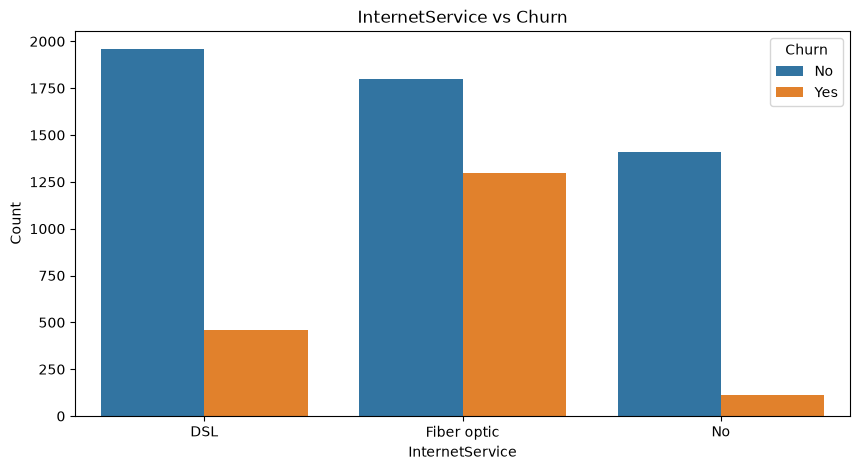


===== Churn Rate by InternetService =====


InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64

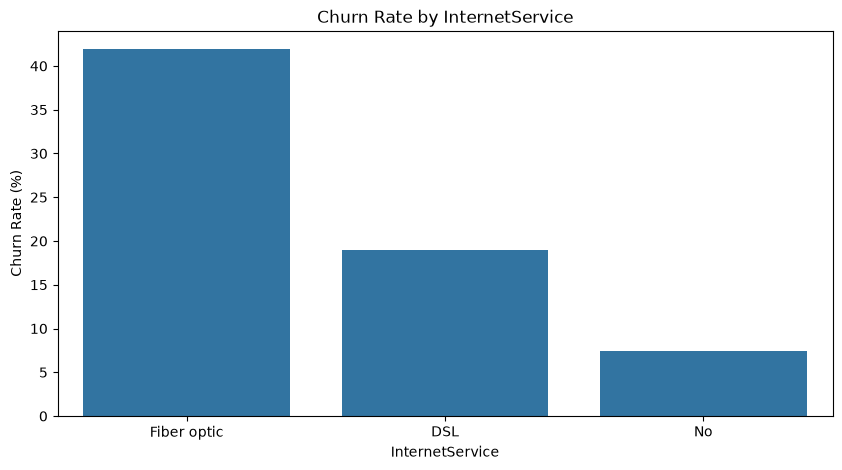


===== Crosstab: TechSupport vs Churn =====


Churn,No,Yes
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


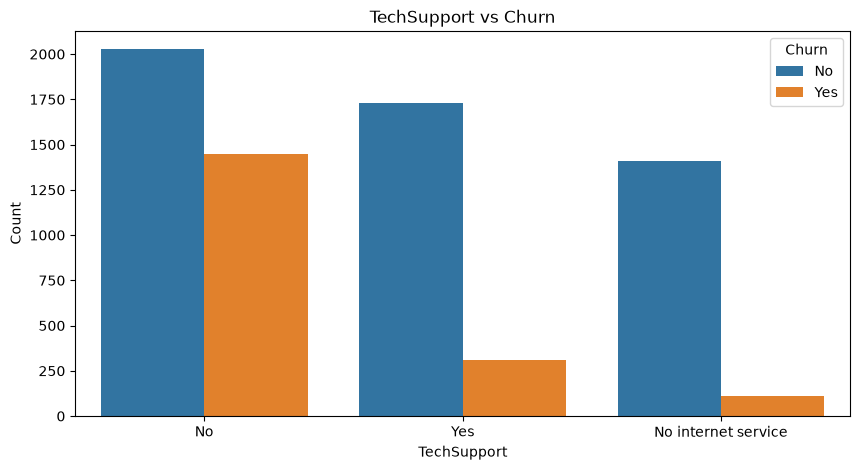


===== Churn Rate by TechSupport =====


TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn, dtype: float64

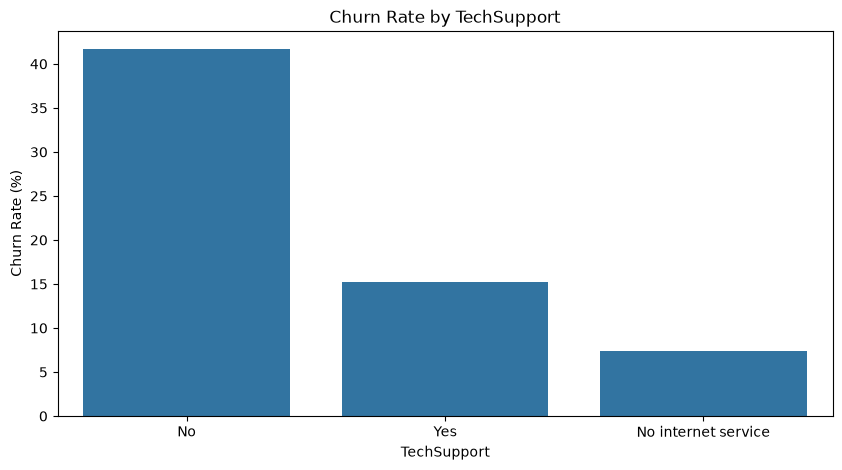


===== Crosstab: OnlineSecurity vs Churn =====


Churn,No,Yes
OnlineSecurity,,
No,2036,1461
No internet service,1407,113
Yes,1720,295


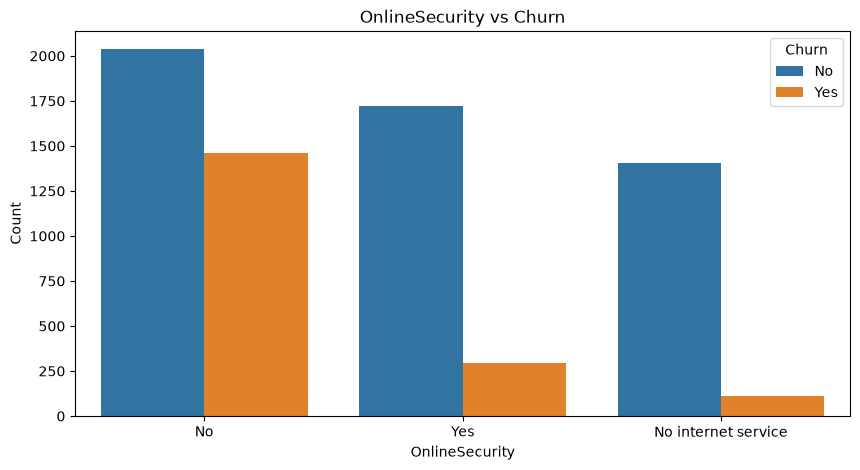


===== Churn Rate by OnlineSecurity =====


OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn, dtype: float64

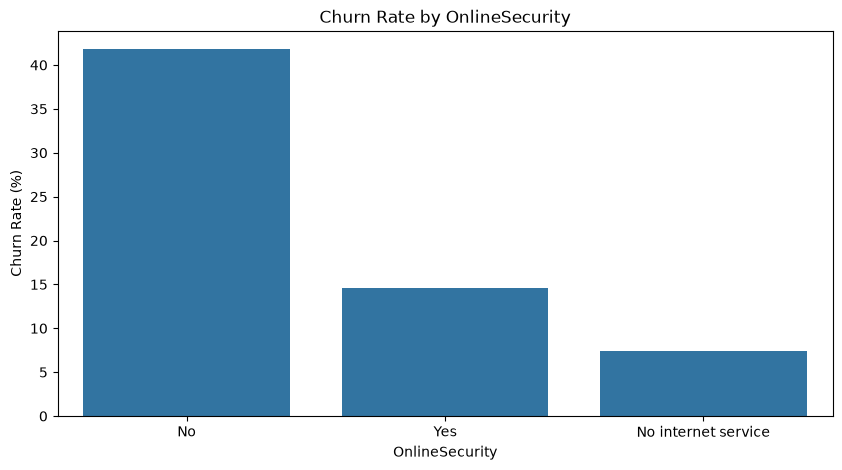


===== Crosstab: PaperlessBilling vs Churn =====


Churn,No,Yes
PaperlessBilling,,
No,2395,469
Yes,2768,1400


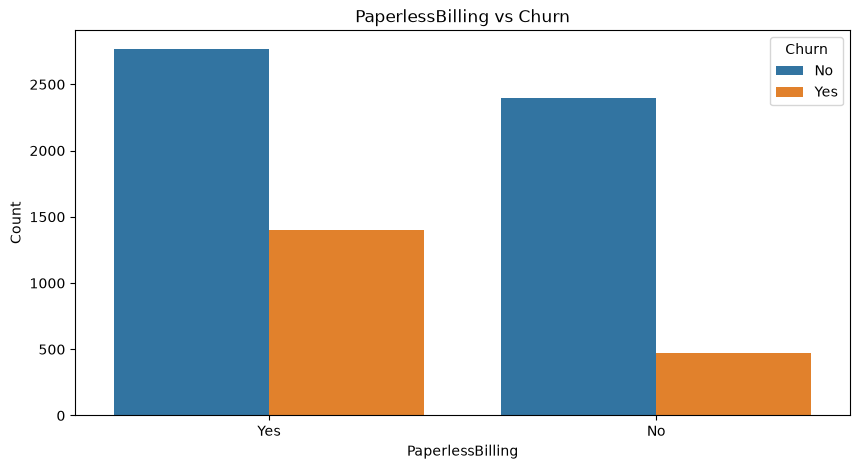


===== Churn Rate by PaperlessBilling =====


PaperlessBilling
Yes    33.589251
No     16.375698
Name: Churn, dtype: float64

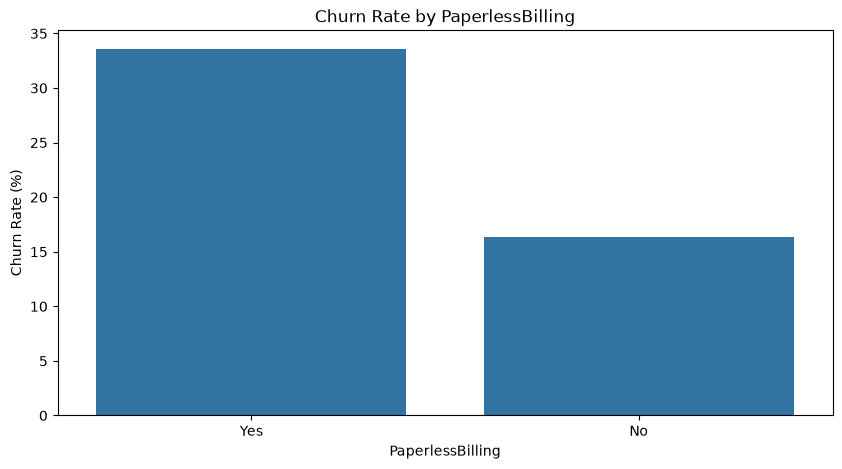

In [72]:
categorical_vs_churn(df, "InternetService")
categorical_vs_churn(df, "TechSupport")
categorical_vs_churn(df, "OnlineSecurity")
categorical_vs_churn(df, "PaperlessBilling")

## Section: Bivariate Analysis — Demographic Features vs Churn


===== Crosstab: gender vs Churn =====


Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


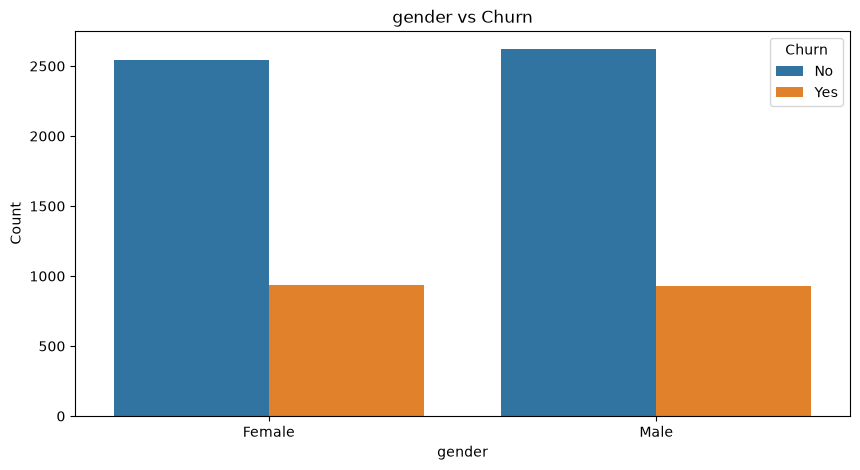


===== Churn Rate by gender =====


gender
Female    26.959518
Male      26.204565
Name: Churn, dtype: float64

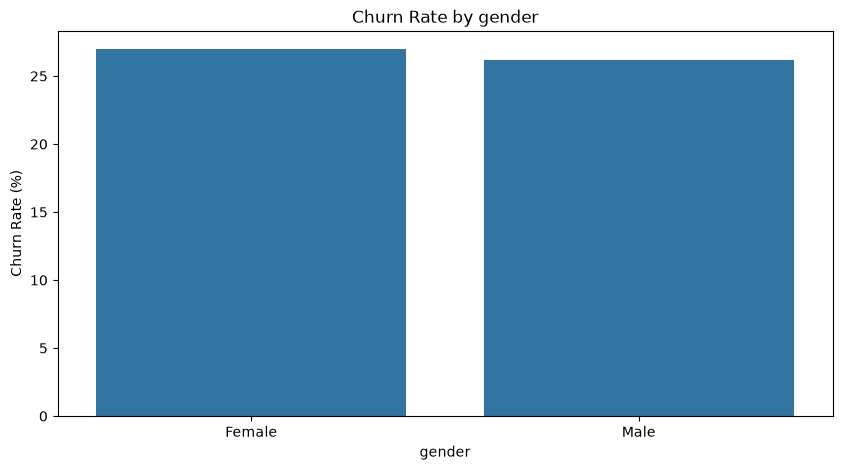


===== Crosstab: SeniorCitizen vs Churn =====


Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


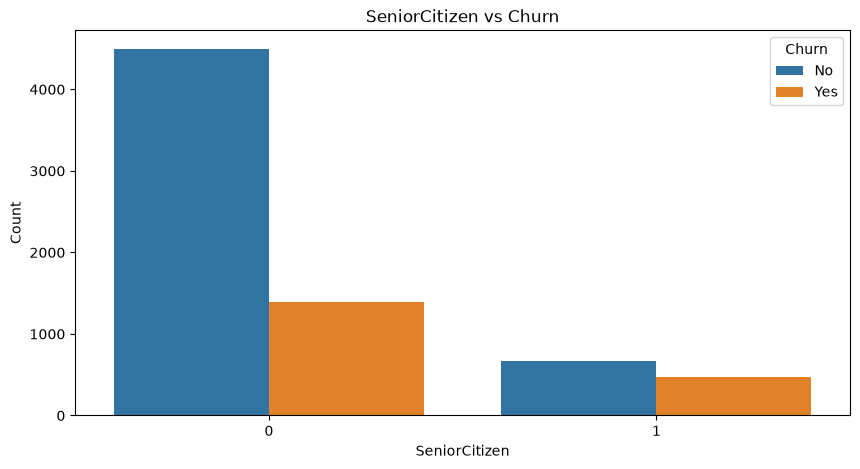


===== Churn Rate by SeniorCitizen =====


SeniorCitizen
1    41.681261
0    23.650255
Name: Churn, dtype: float64

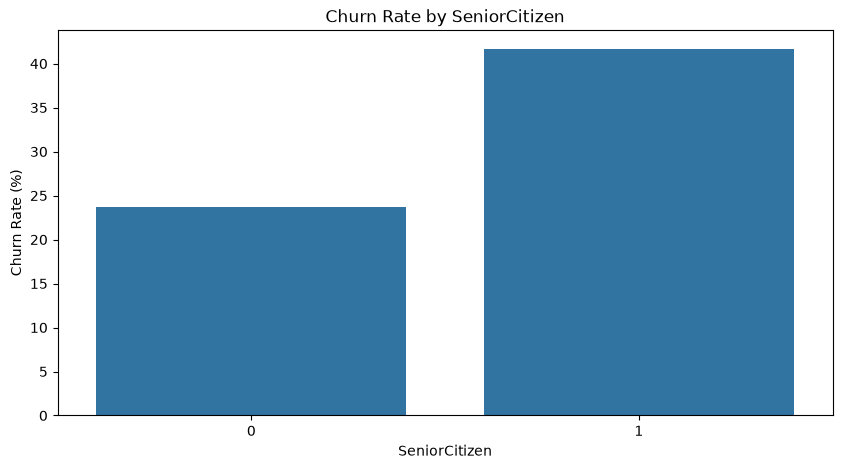


===== Crosstab: Partner vs Churn =====


Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


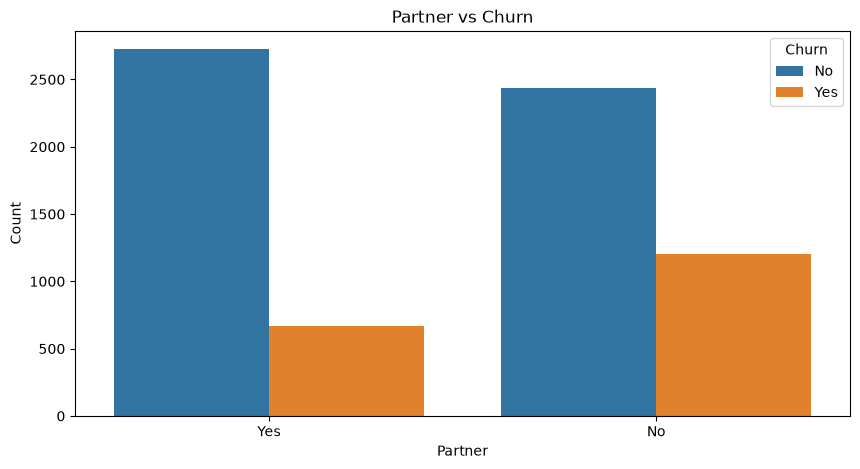


===== Churn Rate by Partner =====


Partner
No     32.976092
Yes    19.717065
Name: Churn, dtype: float64

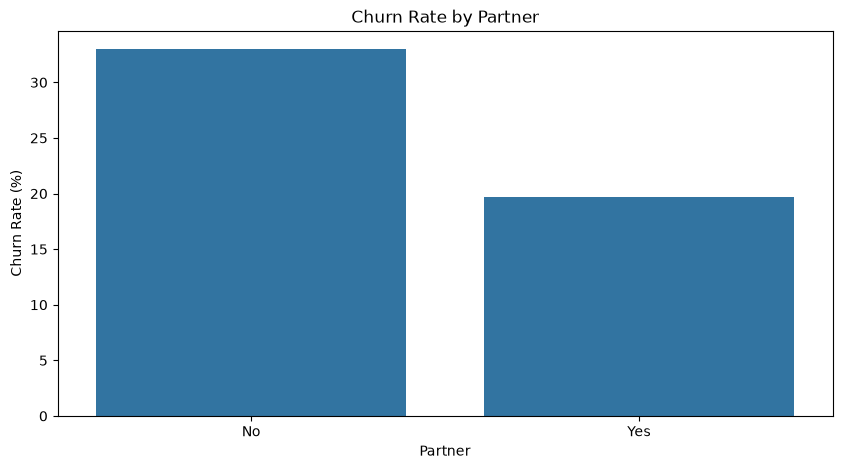


===== Crosstab: Dependents vs Churn =====


Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


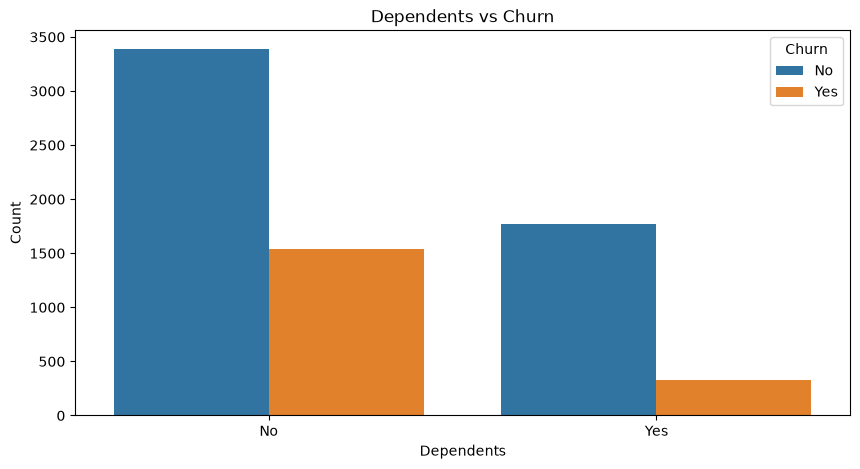


===== Churn Rate by Dependents =====


Dependents
No     31.279140
Yes    15.531205
Name: Churn, dtype: float64

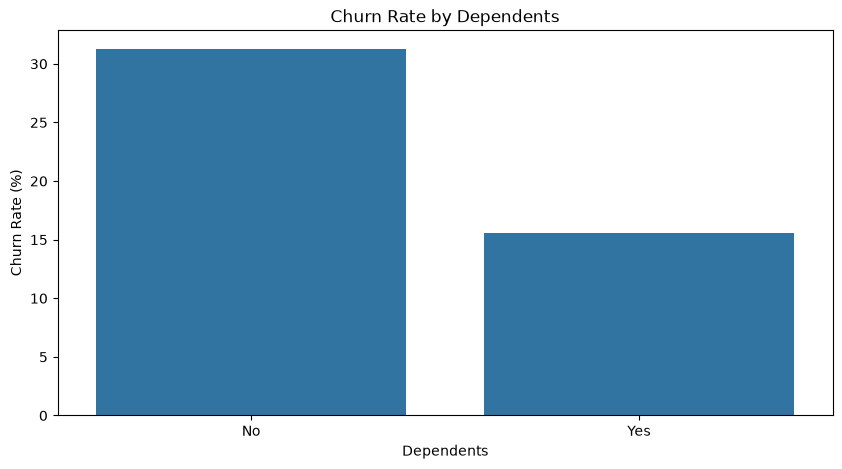

In [69]:
categorical_vs_churn(df, "gender")
categorical_vs_churn(df, "SeniorCitizen")
categorical_vs_churn(df, "Partner")
categorical_vs_churn(df, "Dependents")

## numerical features v/s churn 

In [74]:
def numerical_vs_churn(df, col, target="Churn", figsize=(8,5)):
    # Summary stats by churn
    print(f"\n===== Summary stats: {col} by {target} =====")
    display(df.groupby(target)[col].describe())

    # Boxplot
    plt.figure(figsize=figsize)
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"{col} vs {target}")
    plt.xlabel(target)
    plt.ylabel(col)
    plt.show()

    # KDE / histogram split by churn
    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=col, hue=target, kde=True, bins=30, element="step")
    plt.title(f"Distribution of {col} by {target}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


===== Summary stats: tenure by Churn =====


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


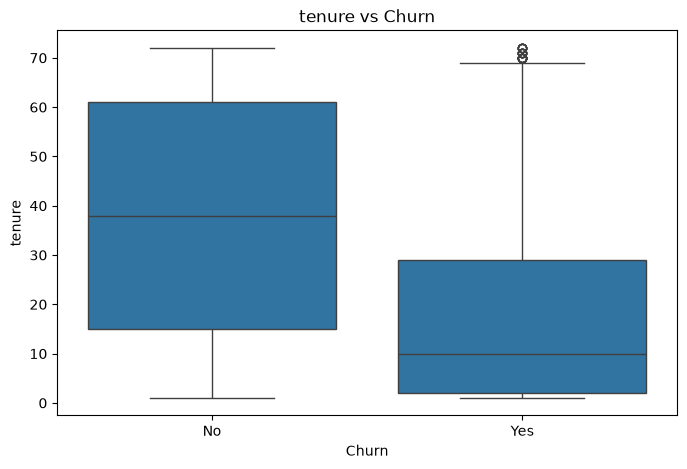

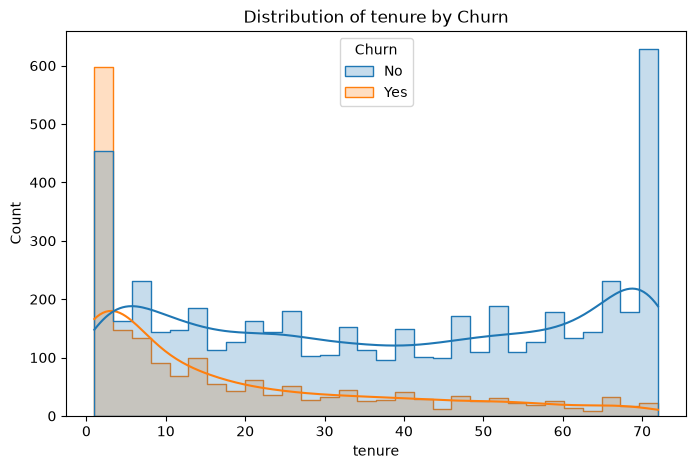


===== Summary stats: MonthlyCharges by Churn =====


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


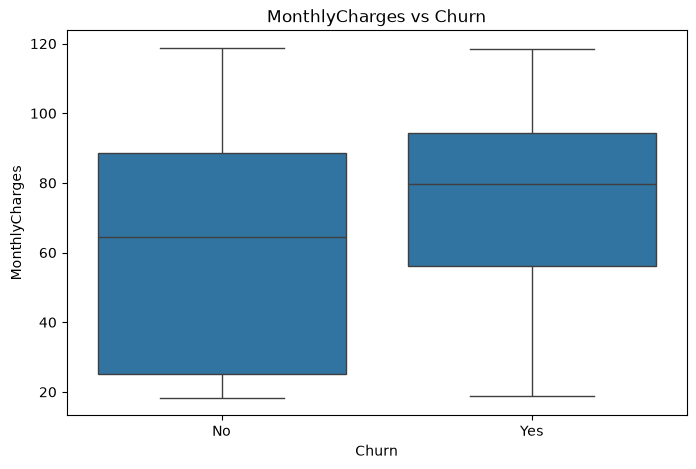

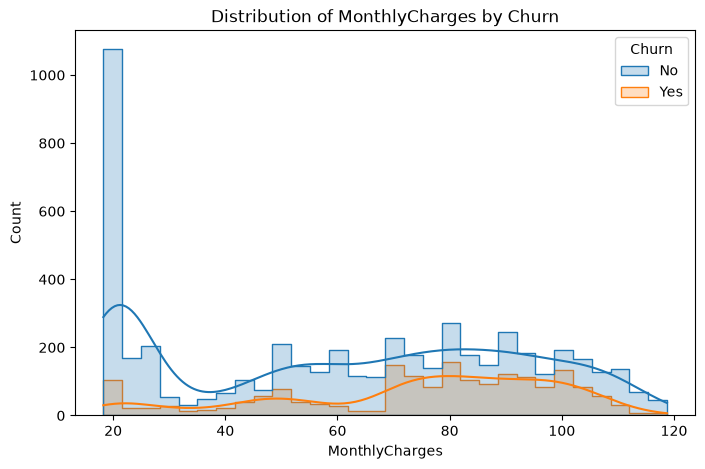


===== Summary stats: TotalCharges by Churn =====


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


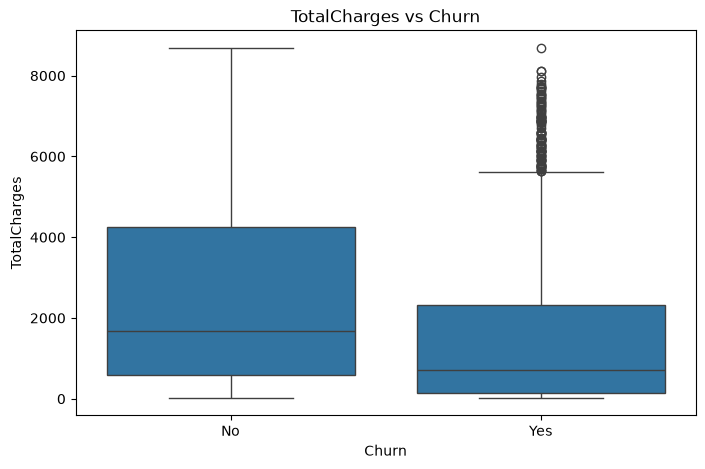

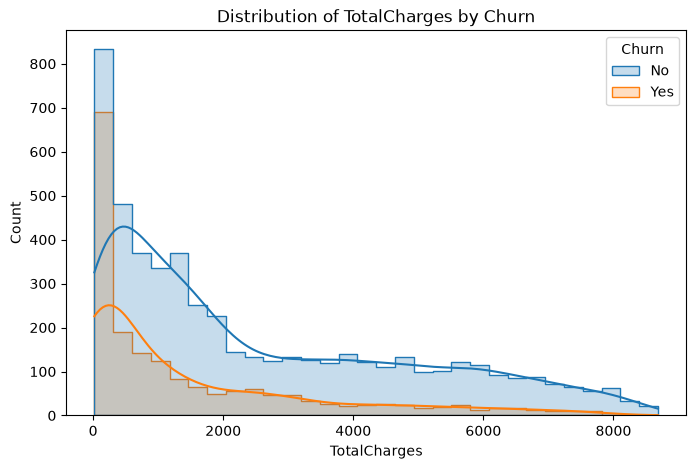

In [75]:
numerical_vs_churn(df, "tenure")
numerical_vs_churn(df, "MonthlyCharges")
numerical_vs_churn(df, "TotalCharges")

## Bivariate Analysis

Bivariate analysis studies the relationship between **two variables**.  
In this project, we mainly use it to understand how each feature relates to the target variable **`Churn`**.

### Why do we do bivariate analysis?
- To check whether a feature is associated with churn
- To identify strong churn drivers
- To compare churn behavior across different feature values
- To generate business insights before modeling

---

## 1. Numerical Feature vs Churn
Used when the feature is numeric, such as:
- `tenure`
- `MonthlyCharges`
- `TotalCharges`

### What we use:
- **Boxplot** → compares the distribution of the numeric feature across churn classes (`Yes` vs `No`)
- **Histogram / KDE with hue = Churn** → shows how the feature is distributed for churned vs non-churned customers
- **Grouped summary statistics** (`groupby("Churn")[col].describe()`) → compares mean, median, spread, etc.

### Goal:
To see whether churned and non-churned customers differ in terms of:
- central tendency
- spread
- skewness
- overall distribution

---

## 2. Categorical Feature vs Churn
Used when the feature is categorical, such as:
- `Contract`
- `PaymentMethod`
- `InternetService`
- `TechSupport`

### What we use:
- **Crosstab** → shows raw counts of churned and non-churned customers in each category
- **Countplot** (`x = category`, `hue = Churn`) → visual comparison of churn counts across categories
- **Churn rate barplot** → shows the percentage of customers who churn within each category

### Goal:
To see whether churn rate changes across categories and identify which categories are more churn-prone.

---

## Summary
- **Numerical vs Churn** → Boxplot + Histogram/KDE + Summary statistics
- **Categorical vs Churn** → Crosstab + Countplot + Churn-rate barplot